In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [56]:
data=pd.read_csv("insurance.csv")

In [57]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [58]:
data.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [59]:
data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [60]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


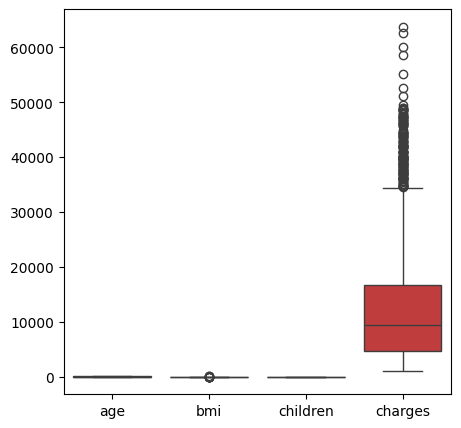

In [61]:
plt.figure(figsize=(5,5))
sns.boxplot(data=data)
plt.show()


In [62]:
numeric_cols = data.select_dtypes(include=np.number)

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    data = data[(data[col] >= lower) & (data[col] <= upper)]

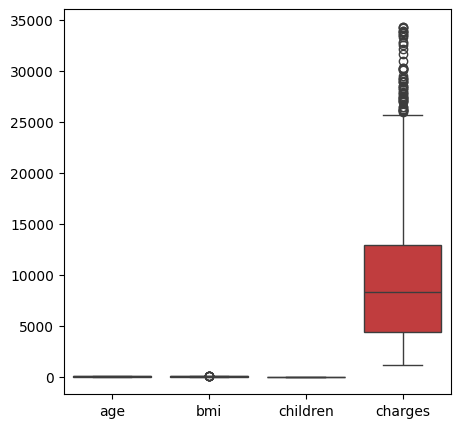

In [63]:
plt.figure(figsize=(5,5))
sns.boxplot(data=data)
plt.show()

In [64]:
data["BMI Category"]=data["bmi"].apply(lambda x:"Underweight" if x < 18.5 
    else "Normal" if x < 25 
    else "Overweight" if x < 30 
    else "Obese")

In [65]:
data

,age,sex,bmi,children,smoker,region,charges,BMI Category
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,Obese
1334,18,female,31.920,0,no,northeast,2205.98080,Obese
1335,18,female,36.850,0,no,southeast,1629.83350,Obese
1336,21,female,25.800,0,no,southwest,2007.94500,Overweight


In [66]:
data["smoker"] = data["smoker"].map({"yes":1, "no":0})

data["Interaction"]=data["bmi"]*data["smoker"]

In [67]:
data

,age,sex,bmi,children,smoker,region,charges,BMI Category,Interaction
0,19,female,27.900,0,1,southwest,16884.92400,Overweight,27.90
1,18,male,33.770,1,0,southeast,1725.55230,Obese,0.00
2,28,male,33.000,3,0,southeast,4449.46200,Obese,0.00
3,33,male,22.705,0,0,northwest,21984.47061,Normal,0.00
4,32,male,28.880,0,0,northwest,3866.85520,Overweight,0.00
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,0,northwest,10600.54830,Obese,0.00
1334,18,female,31.920,0,0,northeast,2205.98080,Obese,0.00
1335,18,female,36.850,0,0,southeast,1629.83350,Obese,0.00
1336,21,female,25.800,0,0,southwest,2007.94500,Overweight,0.00


In [72]:
x=data[["age","bmi","children","smoker","Interaction"]]
y=data["charges"]
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)


In [69]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print(mae)

2567.0380172309397


In [70]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

R2 Score: 0.6390806809438945
RMSE: 4420.228806658116


In [71]:
import pickle

pickle.dump(model, open("insurance_model.pkl", "wb"))